In [2]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.miscmodels.ordinal_model import OrderedModel
import statsmodels.formula.api as smf
import re
import seaborn as sns
import pickle

ANES_YEAR_MIN = 1972 # Lower limit of years to consider for ANES-based model

#TODO: Read anes data from compressed file to stay below GitHub file size limit of 100 MB
anes_full = pd.read_csv('raw_data/anes_timeseries_cdf_csv_20260205/anes_timeseries_cdf_csv_20260205.csv')
anes_full = anes_full.rename(columns={
    "VCF0803": "voter_ideo", #Ideological self-placement scale
    "VCF9096": "gop_ideo", #Respondent rating of gop candidate on ideology scale
    "VCF9088": "dem_ideo", #Respondentt rating of dem candidate on ideology scale
    "VCF0830": "voter_resent", #Government aid to blacks question, selected due to time continuity from 1972-2024
    "VCF9092": "gop_resent", #Respondent rating of gop candidate on gov't aid to blacks
    "VCF9084": "dem_resent", #Respondent rating of dem candidate on gov't aid to blacks
    "VCF0901a": "state_fips",
    "VCF0004": "year",
    "VCF0704a": "vote_pres",
    "VCF0009z": "weightz"})
anes_full['state_fips'] = pd.to_numeric(anes_full['state_fips'], errors='coerce').astype('Int64')

# Merge with state postal codes (for interpretability) and region codes
state_codes = pd.read_csv('raw_data/state_fips.csv')
anes_full = pd.merge(anes_full, state_codes, on='state_fips', how='left')
regions = pd.read_csv('raw_data/us_regions_divisions.csv')
regions = regions.rename(columns = {'State': 'state_name', 'State Code': 'state', 'Region': 'census_region', 'Division': 'division'})
anes_full = pd.merge(anes_full, regions[['state','census_region','division']], on = 'state', how = 'left')
bea_regions = pd.read_csv('raw_data/statelevel_predictors.csv')
anes_full = pd.merge(anes_full, bea_regions[['state','bea_region','pol_south']], on = 'state', how = 'left')

# Add state partisanship data to better predict distribution of ideology within states
state_partisanship = pd.read_stata('raw_data/1868_2020_presvote.dta')
state_partisanship['natl_rvote'] = (state_partisanship.groupby('year')['rvote']
        .transform(lambda x: x[state_partisanship.loc[x.index, 'state'] == 'US'].iloc[0]))
state_partisanship['rlean'] = state_partisanship['rvote'] - state_partisanship['natl_rvote']
state_partisanship['rlean_rolling2'] = (state_partisanship.groupby('state')['rlean']
        .rolling(window = 2, min_periods = 1).mean().reset_index(level=0, drop=True) 
)
state_partisanship = state_partisanship[state_partisanship['year'] >= ANES_YEAR_MIN]
#anes_full = pd.merge(anes_full, state_partisanship[['year','state','rlean','rlean_rolling2']], on = ['state', 'year'], how = 'left')
#anes_full['rlean'] = anes_full.groupby('state')['rlean'].ffill() #fill missing values in mid-election year with rlean from previous year
#anes_full['rlean_rolling2'] = anes_full.groupby('state')['rlean_rolling2'].ffill()
# TODO: Extract 'totev' from the state partisanship data to model electoral votes

# Join mass economic and policy liberalism measures from Caughey Warshaw 2018 with ANES respondent ideology data
caughey_warshaw = pd.read_stata('raw_data/caughey_warshaw_summary.dta')
caughey_warshaw = caughey_warshaw.rename(columns = {'stpo': 'state'})
caughey_warshaw['year'] = caughey_warshaw['year'].astype('int64')

#Merge all state-year data into a dataframe where each row corresponds to unique combo of year and state
merged_covariates = pd.MultiIndex.from_product([anes_full['year'].unique(), anes_full['state'].unique()], 
                                                        names=['year', 'state']).to_frame(index=False)
merged_covariates = (merged_covariates
    .merge(state_partisanship[['year','state','rlean','rlean_rolling2']], how='left', on=['year','state'])
    .merge(caughey_warshaw[['year','state','masseconlib_est','masssociallib_est']], how='left', on=['year','state'])
)
merged_covariates['rlean'] = merged_covariates.groupby('state')['rlean'].ffill() #fill missing values in mid-election year with rlean from previous year
merged_covariates['rlean_rolling2'] = merged_covariates.groupby('state')['rlean_rolling2'].ffill()
#extrapolate most recent estimates in 2014 to 2024
merged_covariates['masseconlib_est'] = merged_covariates.groupby('state')['masseconlib_est'].ffill()
merged_covariates['masssociallib_est'] = merged_covariates.groupby('state')['masssociallib_est'].ffill()

#Set liberalism of DC to most liberal state, within each year
merged_p56 = merged_covariates[merged_covariates['year'] >= 1956]
idx_max_sociallib = merged_p56.groupby('year')['masssociallib_est'].idxmax()
dc_sociallib = merged_p56.loc[idx_max_sociallib, ['masssociallib_est','year']].rename(columns = {'masssociallib_est': 'dc_sociallib'})
dc_sociallib['state'] = 'DC'
merged_covariates = pd.merge(merged_covariates, dc_sociallib, how = 'left', on = ['year','state'])
merged_covariates['masssociallib_est'] = merged_covariates['masssociallib_est'].fillna(merged_covariates['dc_sociallib'])
#Re-use code for masseconlib
idx_max_econlib = merged_p56.groupby('year')['masseconlib_est'].idxmax()
dc_econlib = merged_p56.loc[idx_max_econlib, ['masseconlib_est', 'year']].rename(columns = {'masseconlib_est': 'dc_econlib'})
dc_econlib['state'] = 'DC'
merged_covariates = pd.merge(merged_covariates, dc_econlib, how = 'left', on = ['year', 'state'])
merged_covariates['masseconlib_est'] = merged_covariates['masseconlib_est'].fillna(merged_covariates['dc_econlib'])
merged_covariates = merged_covariates.drop(columns = ['dc_sociallib', 'dc_econlib'])

anes_full = pd.merge(anes_full, merged_covariates, how = 'left', on = ['year', 'state'])

#Process individual-level variables within ANES table
anes_full['voter_ideo'] = pd.to_numeric(anes_full['voter_ideo'], errors='coerce')
anes_full['voter_ideo'] = anes_full['voter_ideo'].apply(lambda x: np.nan if x == 9.0 or x == 0.0 else x)
anes_full['voter_resent'] = pd.to_numeric(anes_full['voter_resent'], errors='coerce')
anes_full['voter_resent'] = anes_full['voter_resent'].apply(lambda x: np.nan if x == 9.0 or x == 0.0 else x)
anes_full['gop_ideo'] = pd.to_numeric(anes_full['gop_ideo'], errors='coerce')
anes_full['dem_ideo'] = pd.to_numeric(anes_full['dem_ideo'], errors='coerce')
anes_full['gop_resent'] = pd.to_numeric(anes_full['gop_resent'], errors='coerce')
anes_full['dem_resent'] = pd.to_numeric(anes_full['dem_resent'], errors='coerce')
cols = ['gop_ideo','dem_ideo','gop_resent','dem_resent']
#Recode missing, don't know, or other inapplicable responses to NA
anes_full[cols] = anes_full[cols].replace([8, 9, 0], np.nan)
#GOP ideology appears to be coded in reverse in 2024 
anes_full.loc[anes_full['year'] == 2024, 'gop_ideo'] = 8 - anes_full.loc[anes_full['year'] == 2024, 'gop_ideo']
#Aid to blacks scale not measured in 1992; impute with previous election year's value
anes_full.loc[anes_full['year'] == 1992, 'gop_resent'] = anes_full.loc[anes_full['year'] == 1988, 'gop_resent'].mean()
anes_full.loc[anes_full['year'] == 1992, 'dem_resent'] = anes_full.loc[anes_full['year'] == 1988, 'dem_resent'].mean()

## Create predictor variables for ordinal model
anes_full['state_fips'] = anes_full['state_fips'].astype('string')
anes_full['decade'] = ((anes_full['year'] // 10) * 10).astype('string')
#anes['year_categorical'] = anes['year'].astype('category')
anes_full['year_center'] = anes_full['year'] - 2000
anes_full['year_center_sq'] = anes_full['year_center']**2

#Re-code party choice for president
anes_full['vote_pres'] = pd.to_numeric(anes_full['vote_pres'], errors='coerce')
anes_full['vote_pres'] = anes_full['vote_pres'].apply(lambda x: 'Democrat' if x == 1 else 'Republican' if x == 2 else np.nan)

#Compute voter distance from each candidate
#Take absolute value of distance because it is a better predictor than squared distance
anes_full['delta_dem_ideo_indiv'] = abs(anes_full['voter_ideo'] - anes_full['dem_ideo'])
anes_full['delta_gop_ideo_indiv'] = abs(anes_full['voter_ideo'] - anes_full['gop_ideo'])
anes_full['delta_dem_resent_indiv'] = abs(anes_full['voter_resent'] - anes_full['gop_resent']) 
anes_full['delta_gop_resent_indiv'] = abs(anes_full['voter_resent'] - anes_full['dem_resent'])
#Compute voter utility w.r.t. average rating of candidate ideology
anes_full['delta_dem_ideo'] = abs(anes_full.groupby('state')['dem_ideo'].transform('mean') 
                           - anes_full['voter_ideo'])
anes_full['delta_gop_ideo'] = abs(anes_full.groupby('state')['gop_ideo'].transform('mean') 
                           - anes_full['voter_ideo'])
anes_full['delta_dem_resent'] = abs(anes_full.groupby('state')['dem_resent'].transform('mean') 
                              - anes_full['voter_resent'])
anes_full['delta_gop_resent'] = abs(anes_full.groupby('state')['gop_resent'].transform('mean') 
                              - anes_full['voter_resent'])

#Add national economic indicators to individual-level ANES
state_time_series_data = pd.read_csv('raw_data/regression_data.csv')
state_cols = ['inc_pres','inc_tenure','gdp_yoy','inflation_yoy','unemployment',
              'lean_current','partisan_lean','lean_prev','lean_prev2','lean_prev3','lean_prev4', #state partisan lean relative to nation over the previous four presidential election (4yr inteval)
              'hlean_prev','hlean_prev2','hlean_prev3','hlean_prev4'] #state partisan lean in House of Rep. elections over previous four congressional elections (NOTE: 2yr interval; not comparable to lean_prev)
anes_full = pd.merge(anes_full, state_time_series_data[['year','state'] + state_cols], on = ['year','state'])
anes_full['partisan_lean'] = (anes_full['lean_prev'] + anes_full['lean_prev2']) / 2


anes_full['vote_pres_bin'] = anes_full['vote_pres'].map({'Democrat': 1, 'Republican': 0})
#In the single party case, we may only model vote probability as a function of opinion distance of the voter from the candidate i
#Multiparty regression models use the distance from the democratic candidate and the reference party (Democrats are chosen because the R^2 is higher)
anes_full['i_ideo'] = anes_full.groupby('state')['dem_ideo'].transform('mean')
anes_full['i_resent'] = anes_full.groupby('state')['dem_resent'].transform('mean')
anes_full['delta_i_ideo'] = anes_full['delta_dem_ideo']
anes_full['delta_i_resent'] = anes_full['delta_dem_resent']

anes = anes_full[[
    'state','state_fips', 'weightz',
    'voter_ideo','voter_resent',
    'i_ideo','i_resent',#In two-party case P(vote for dem) = Distance(voter, gop) - Distance(voter, dem); In multi-party case, P(vote for cand. i) = Distance(voter, cand. i)
    'delta_i_ideo', 'delta_i_resent',
    'year', 'year_center', 'year_center_sq', 'decade',
    'census_region','division','bea_region',
    'masseconlib_est', 'masssociallib_est',
    'rlean','rlean_rolling2',
    'vote_pres_bin',
    'dem_ideo', 'gop_ideo', 'dem_resent', 'gop_resent',
    'delta_dem_ideo','delta_gop_ideo','delta_dem_resent','delta_gop_resent',
    'delta_dem_ideo_indiv','delta_gop_ideo_indiv','delta_dem_resent_indiv','delta_gop_resent_indiv'] + 
    state_cols 
    ]
anes = anes[anes['year'] >= ANES_YEAR_MIN]

#Write cleaned anes table to csv; for consistency throughout program, do not modify the ANES variable beyond this point
anes.to_csv('output_data/anes_cleaned.csv')

/var/folders/vh/xl1lkb0j3bbby54dm6r_rm640000gn/T/ipykernel_57575/3381200263.py:14: DtypeWarning: Columns (0: VCF0009x, 1: VCF0010x, 2: VCF0011x, 3: VCF0009y, 4: VCF0010y, 5: VCF0011y, 6: VCF9999, 7: VCF0012, 8: VCF0015a, 9: VCF0015b, 10: VCF0016, 11: VCF0018a, 12: VCF0018b, 13: VCF0019, 14: VCF0050a, 15: VCF0050b, 16: VCF0070a, 17: VCF0070b, 18: VCF0071a, 19: VCF0071b, 20: VCF0071c, 21: VCF0071d, 22: VCF0072a, 23: VCF0072b, 24: VCF0101, 25: VCF0105a, 26: VCF0105b, 27: VCF0106, 28: VCF0107, 29: VCF0108, 30: VCF0109, 31: VCF0111, 32: VCF0112, 33: VCF0113, 34: VCF0114, 35: VCF0115, 36: VCF0116, 37: VCF0117, 38: VCF0118, 39: VCF0119, 40: VCF0120, 41: VCF0121, 42: VCF0122, 43: VCF0123, 44: VCF0124, 45: VCF0125, 46: VCF0126, 47: VCF0126a, 48: VCF0126b, 49: VCF0126c, 50: VCF0127, 51: VCF0127a, 52: VCF0127b, 53: VCF0128, 54: VCF0128a, 55: VCF0128b, 56: VCF0129, 57: VCF0130, 58: VCF0130a, 59: VCF0131, 60: VCF0132, 61: VCF0133, 62: VCF0134, 63: VCF0135, 64: VCF0136, 65: VCF0137, 66: VCF0138, 67:

In [2]:
#Tests to determine whether output data is accurate

#Get state with maximum social liberalism estimate for each year
idx = anes[anes['year'] <= 2000].groupby('year')['masssociallib_est'].idxmax()
anes.loc[idx, ['state', 'masssociallib_est', 'year']]
#anes_full[anes_full['state'] == 'DC'].groupby('year')['masssociallib_est'].agg('mean')

#Check whether DC liberalism has been imputed with the maximum state liberalism value for each year 
(anes_full.loc[anes_full['state'] == 'DC', ['year','state','masssociallib_est','masseconlib_est']]
 .groupby(['year','state']).agg('mean'))

#Check whether the mean placements on the ideology and resentment scales are accurate
pd.DataFrame({'dem_ideo': anes.groupby('year')['dem_ideo'].aggregate('mean'),
                  'gop_ideo': anes.groupby('year')['gop_ideo'].aggregate('mean'),
                  'dem_resent': anes.groupby('year')['dem_resent'].aggregate('mean'),
                  'gop_resent': anes.groupby('year')['gop_resent'].aggregate('mean')})

#idx = anes.groupby('year')['masseconlib_est'].idxmax()
#anes.loc[idx, ['state', 'masseconlib_est', 'year']]
#anes.loc[anes_full['state'] == 'DC', 'masseconlib_est']

,dem_ideo,gop_ideo,dem_resent,gop_resent
year,,,,
1972,2.448994,4.871409,2.655235,4.146080
1976,3.232420,4.908038,3.186739,3.948635
1980,3.739459,5.211726,3.102470,4.965863
1984,3.447020,4.964324,3.186361,4.564615
1988,3.236756,5.114557,3.349779,4.828247
1992,3.186223,5.047244,3.349779,4.828247
1996,3.152363,5.148077,3.315755,4.995882
2000,3.184041,5.019330,3.395965,4.825700
2004,2.987132,5.182657,3.325532,4.955045


In [3]:

ideo_data = anes[['voter_ideo', 'state', 
    'rlean_rolling2', 'masssociallib_est', 'masseconlib_est']].dropna().copy()
ideo_model = OrderedModel.from_formula('voter_ideo ~ state + masseconlib_est + masssociallib_est + rlean_rolling2', 
    distr = 'logit', data = ideo_data, hasconst=False).fit(method = 'cg', disp = True)
ideo_model.summary() #switching to method 'cg' (conjugate gradient) from default Nelder Mead resolves convergence warnings


Optimization terminated successfully.
         Current function value: 1.750305
         Iterations: 375
         Function evaluations: 757
         Gradient evaluations: 757


<class 'statsmodels.iolib.summary.Summary'>
"""
                             OrderedModel Results                             
==============================================================================
Dep. Variable:             voter_ideo   Log-Likelihood:                -55425.
Model:                   OrderedModel   AIC:                         1.110e+05
Method:            Maximum Likelihood   BIC:                         1.115e+05
Date:                Sun, 13 Sep 2026                                         
Time:                        12:00:40                                         
No. Observations:               31666                                         
Df Residuals:                   31607                                         
Df Model:                          53                                         
=====================================================================================
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
state[T.AL]           0.2759      0.433      0.636      0.524      -0.574       1.126
state[T.AR]           0.1992      0.435      0.458      0.647      -0.653       1.052
state[T.AZ]           0.0461      0.433      0.106      0.915      -0.802       0.894
state[T.CA]          -0.0154      0.430     -0.036      0.971      -0.858       0.827
state[T.CO]          -0.2089      0.432     -0.483      0.629      -1.056       0.638
state[T.CT]           0.0423      0.437      0.097      0.923      -0.814       0.898
state[T.DC]          -0.4904      0.483     -1.015      0.310      -1.437       0.457
state[T.DE]          -0.1748      0.478     -0.366      0.715      -1.112       0.762
state[T.FL]           0.1868      0.429      0.435      0.663      -0.654       1.027
state[T.GA]           0.1515      0.430      0.352      0.725      -0.691       0.994
state[T.HI]           0.0595      0.505      0.118      0.906      -0.931       1.050
state[T.IA]           0.1486      0.434      0.342      0.732      -0.703       1.000
state[T.ID]          -0.2262      0.453     -0.499      0.618      -1.114       0.662
state[T.IL]          -0.0152      0.431     -0.035      0.972      -0.859       0.829
state[T.IN]           0.0594      0.431      0.138      0.890      -0.785       0.903
state[T.KS]           0.1521      0.436      0.349      0.727      -0.703       1.007
state[T.KY]          -0.3229      0.438     -0.737      0.461      -1.182       0.536
state[T.LA]           0.1244      0.436      0.285      0.775      -0.730       0.979
state[T.MA]          -0.1285      0.436     -0.295      0.768      -0.982       0.725
state[T.MD]           0.1920      0.435      0.441      0.659      -0.661       1.045
state[T.ME]          -0.0299      0.457     -0.066      0.948      -0.925       0.865
state[T.MI]           0.0660      0.430      0.154      0.878      -0.776       0.908
state[T.MN]           0.0521      0.431      0.121      0.904      -0.793       0.898
state[T.MO]           0.0691      0.431      0.160      0.873      -0.777       0.915
state[T.MS]           0.2995      0.442      0.677      0.498      -0.567       1.166
state[T.MT]          -0.2144      0.483     -0.444      0.657      -1.161       0.733
state[T.NC]          -0.0019      0.430     -0.004      0.996      -0.845       0.841
state[T.ND]           0.2385      0.463      0.516      0.606      -0.668       1.145
state[T.NE]          -0.1475      0.444     -0.332      0.740      -1.019       0.724
state[T.NH]          -0.2564      0.444     -0.578      0.563      -1.126       0.613
state[T.NJ]           0.0861      0.434      0.199      0.843      -0.764       0.936
state[T.NM]           0.1937      0.445      0.436      0.663      -0.678       1.065
state[T.NV]           0.1008      0.449      0.225      0.822      -0.779       0.981
state[T.NY]           0.1115      0.433      0.258      0.797     

In [4]:
YEAR = 2000
masslib = anes[['year','state','masseconlib_est','masssociallib_est']].drop_duplicates()
masslib = masslib.set_index(['state','year'], drop = False)
"""
(ideo_model.predict(pd.DataFrame({
    'state': ['CA','CT','VT'], 

    'masseconlib_est': [masslib.loc[('CA',YEAR),'masseconlib_est'],
        masslib.loc[('CT',YEAR),'masseconlib_est'],
        masslib.loc[('VT',YEAR),'masseconlib_est']],
    'masssociallib_est': [masslib.loc[('CA',YEAR),'masssociallib_est'], 
        masslib.loc[('CT',YEAR),'masssociallib_est'],
        masslib.loc[('VT',YEAR),'masssociallib_est']],

    'year_center': [-20,-20,-20],
    'bea_region': ['Southeast', 'Far West', 'Mideast'], 
    'decade': ['2000','2020','1980'], 
    'rlean_rolling2': [15.5,10.5,-5.5]}))
    .cumsum(axis = 'columns')
)
"""

(ideo_model.predict(pd.DataFrame({
    'state': ['CA','CT','VT'], 
    'rlean_rolling2': [-10.5,-6.7,-8.9],
    'masseconlib_est': [1,0.5,0.8],
    'masssociallib_est': [1,0.5,0.8]}))
    .cumsum(axis = 'columns')
)


,0,1,2,3,4,5,6
0,0.064173,0.269312,0.431752,0.736526,0.855349,0.975830,1.0
1,0.045400,0.203583,0.345102,0.659723,0.803964,0.965519,1.0
2,0.097276,0.366765,0.544206,0.814570,0.902840,0.984483,1.0


In [5]:
resent_data = anes[['voter_resent', 'state', 
    'rlean_rolling2', 'masssociallib_est', 'masseconlib_est']].dropna().copy()
resent_model = OrderedModel.from_formula('voter_resent ~ state + masseconlib_est + masssociallib_est + rlean_rolling2', 
    distr = 'logit', data = resent_data, hasconst=False).fit(method = 'cg', disp = True)

resent_model.summary() #switching to method 'cg' (conjugate gradient) from default Nelder Mead resolves convergence warnings


Optimization terminated successfully.
         Current function value: 1.879367
         Iterations: 292
         Function evaluations: 617
         Gradient evaluations: 617


<class 'statsmodels.iolib.summary.Summary'>
"""
                             OrderedModel Results                             
==============================================================================
Dep. Variable:           voter_resent   Log-Likelihood:                -66704.
Model:                   OrderedModel   AIC:                         1.335e+05
Method:            Maximum Likelihood   BIC:                         1.340e+05
Date:                Sun, 13 Sep 2026                                         
Time:                        12:03:11                                         
No. Observations:               35493                                         
Df Residuals:                   35434                                         
Df Model:                          53                                         
=====================================================================================
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
state[T.AL]           0.1306      0.501      0.260      0.795      -0.852       1.113
state[T.AR]           0.1618      0.502      0.322      0.747      -0.823       1.147
state[T.AZ]           0.2179      0.501      0.435      0.664      -0.765       1.200
state[T.CA]          -0.1104      0.499     -0.221      0.825      -1.089       0.868
state[T.CO]           0.0238      0.500      0.047      0.962      -0.957       1.004
state[T.CT]          -0.2060      0.504     -0.409      0.683      -1.194       0.782
state[T.DC]          -0.7008      0.536     -1.307      0.191      -1.752       0.350
state[T.DE]          -0.1582      0.534     -0.296      0.767      -1.205       0.889
state[T.FL]           0.1082      0.498      0.217      0.828      -0.869       1.085
state[T.GA]          -0.0609      0.499     -0.122      0.903      -1.039       0.917
state[T.HI]           0.4060      0.563      0.721      0.471      -0.698       1.510
state[T.IA]           0.1593      0.502      0.318      0.751      -0.824       1.143
state[T.ID]          -0.0848      0.517     -0.164      0.870      -1.098       0.928
state[T.IL]          -0.1626      0.500     -0.325      0.745      -1.142       0.817
state[T.IN]           0.1518      0.499      0.304      0.761      -0.827       1.131
state[T.KS]           0.0698      0.503      0.139      0.890      -0.917       1.056
state[T.KY]           0.0605      0.505      0.120      0.905      -0.929       1.050
state[T.LA]           0.1022      0.503      0.203      0.839      -0.884       1.089
state[T.MA]          -0.2019      0.504     -0.401      0.689      -1.189       0.785
state[T.MD]          -0.0612      0.503     -0.121      0.903      -1.048       0.926
state[T.ME]          -0.3066      0.521     -0.589      0.556      -1.327       0.714
state[T.MI]          -0.0095      0.499     -0.019      0.985      -0.987       0.969
state[T.MN]           0.1149      0.500      0.230      0.818      -0.865       1.095
state[T.MO]           0.1854      0.500      0.370      0.711      -0.795       1.166
state[T.MS]          -0.0654      0.509     -0.128      0.898      -1.063       0.932
state[T.MT]           0.2739      0.542      0.506      0.613      -0.788       1.336
state[T.NC]          -0.1143      0.500     -0.229      0.819      -1.093       0.865
state[T.ND]           0.5215      0.529      0.987      0.324      -0.515       1.558
state[T.NE]           0.3071      0.510      0.603      0.547      -0.692       1.306
state[T.NH]          -0.1301      0.509     -0.255      0.798      -1.129       0.868
state[T.NJ]           0.0577      0.502      0.115      0.909      -0.927       1.042
state[T.NM]           0.0837      0.511      0.164      0.870      -0.918       1.086
state[T.NV]           0.3005      0.515      0.583      0.560      -0.709       1.310
state[T.NY]          -0.2276      0.502     -0.454      0.650     

In [6]:
(resent_model.predict(pd.DataFrame({
    'state': ['AK','MS','NJ'],  
    'rlean_rolling2': [15.5,16.2,-5],
    'masseconlib_est': [0.5,0.3,1.2],
    'masssociallib_est': [0.5,0.3,1.2]}))
    .cumsum(axis = 'columns')
)

,0,1,2,3,4,5,6
0,0.072752,0.127741,0.214786,0.433453,0.577989,0.738404,1.0
1,0.081202,0.141603,0.235542,0.462884,0.606724,0.760738,1.0
2,0.074681,0.130923,0.219590,0.440405,0.584866,0.743826,1.0


In [7]:
#Create table containing covariates of each state for every election year from 1972-2024 to predict
# distribution of self-placement in each state. Plot average public opinion in each state to visually assess
# estimates

model_covars = list(set(re.split(r'\W+', ideo_model.model.formula)) |
     set(re.split(r'\W+', resent_model.model.formula)))
model_covars.remove('voter_ideo')
model_covars.remove('voter_resent') #Create dataframe of predictor variables; remove outcomes

state_ideology_time_series = merged_covariates.copy()
state_ideology_time_series = state_ideology_time_series.reset_index()
#model_covars_nyear.remove('state') #Check that getting first column is same as getting mean
#y = anes.groupby(['year','state'])[model_covars_nyear].agg('mean')

#Add the estimated pdf of ideology and resentment within each state and time period
ideo_model_mat = ideo_model.predict(state_ideology_time_series).reset_index()
resent_model_mat = resent_model.predict(state_ideology_time_series).reset_index()
state_ideology_time_series = (pd.concat([ideo_model_mat, state_ideology_time_series], axis = 1)
                              .rename(columns = dict(zip(ideo_model_mat.keys() , 
                                                         [f'ideo_{c}' for c in ideo_model_mat.keys()])) ) )
state_ideology_time_series = (pd.concat([resent_model_mat, state_ideology_time_series], axis = 1)
                              .rename(columns = dict(zip(resent_model_mat.keys() , 
                                                         [f'resent_{c}' for c in resent_model_mat.keys()])) ) )
state_ideology_time_series = (state_ideology_time_series
                              .drop(columns=state_ideology_time_series
                                    .filter(regex='index').columns))

#Compute the proportion placing themselves below four along each scale
state_ideology_time_series['predict_ideo4'] = ideo_model.predict(state_ideology_time_series).cumsum(axis = 'columns')[4]
state_ideology_time_series['predict_resent4'] = resent_model.predict(state_ideology_time_series).cumsum(axis = 'columns')[4]

state_ideology_time_series = state_ideology_time_series[
    ['year', 'state'] + [c for c in state_ideology_time_series.columns if c not in ['year', 'state']]
]

#Save estimated distribution of resentment and ideology in states over time to prevent unnecessarily re-fitting the models
state_ideology_time_series.to_csv('output_data/state_ideology_ts.csv')


In [13]:
state_ideology_time_series.keys()

Index(['year', 'state', 'resent_0', 'resent_1', 'resent_2', 'resent_3',
       'resent_4', 'resent_5', 'resent_6', 'ideo_0', 'ideo_1', 'ideo_2',
       'ideo_3', 'ideo_4', 'ideo_5', 'ideo_6', 'rlean', 'rlean_rolling2',
       'masseconlib_est', 'masssociallib_est', 'predict_ideo4',
       'predict_resent4'],
      dtype='str')

/var/folders/vh/xl1lkb0j3bbby54dm6r_rm640000gn/T/ipykernel_57575/4177730988.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.825, 0.99])


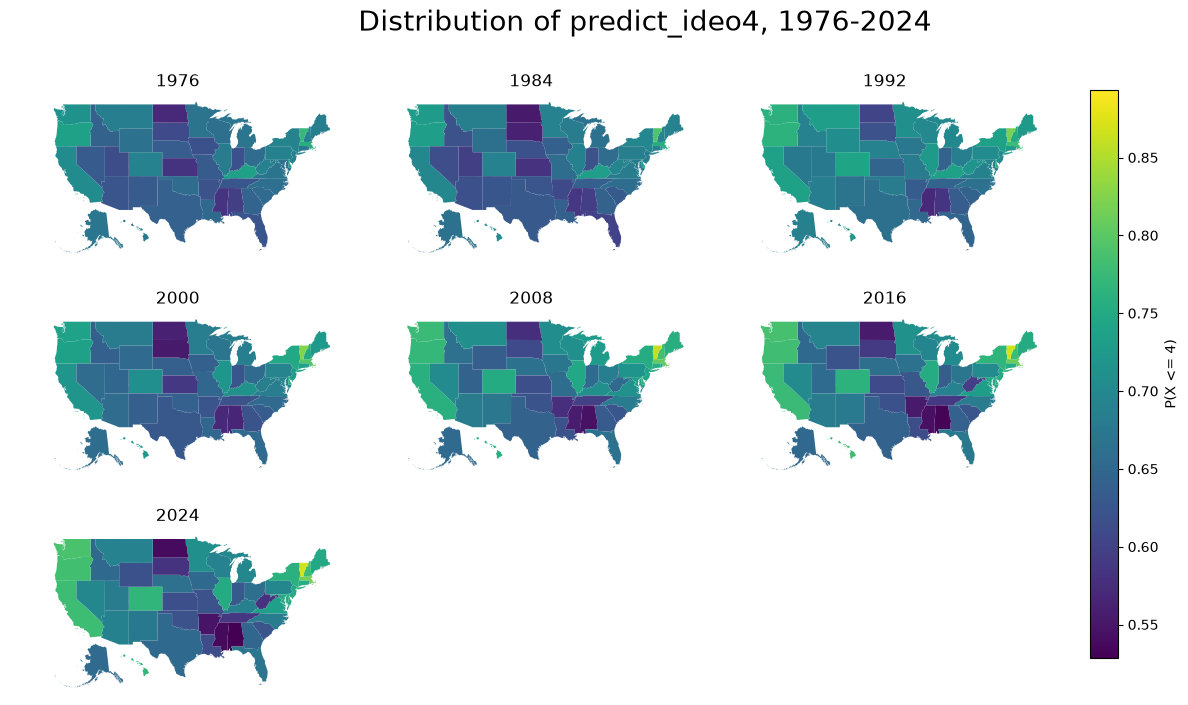

/var/folders/vh/xl1lkb0j3bbby54dm6r_rm640000gn/T/ipykernel_57575/4177730988.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.825, 0.99])


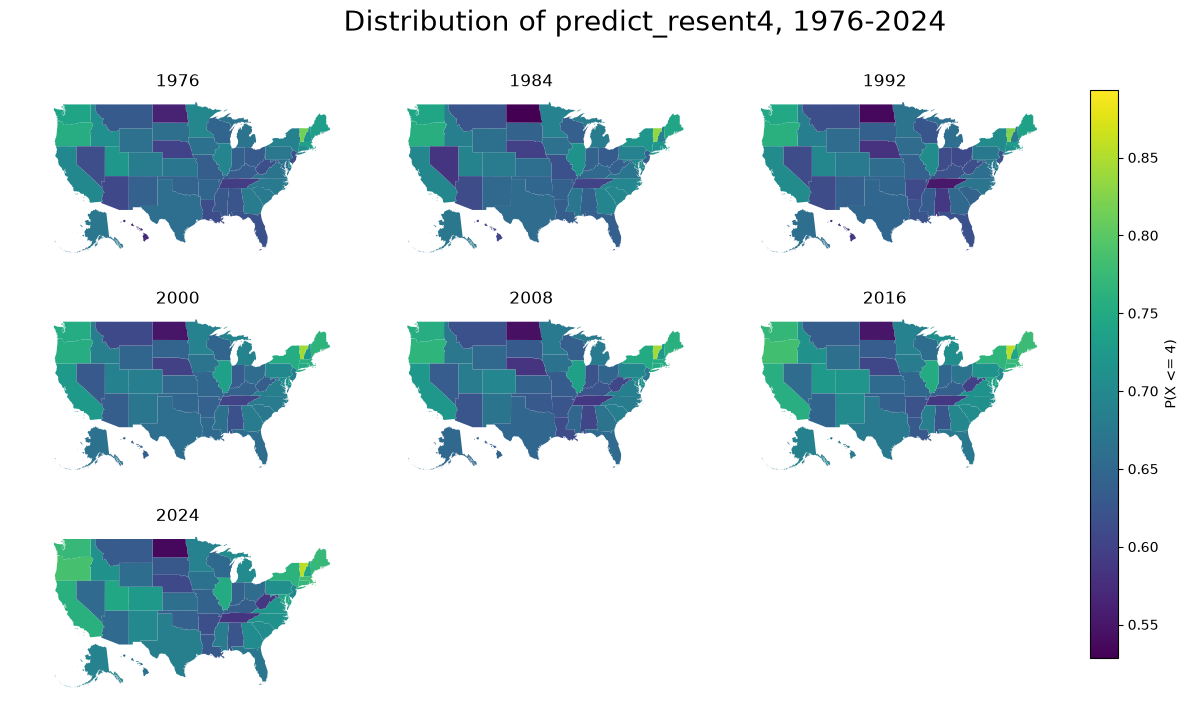

In [7]:
"""Load the greater US shapefile data in the working directory under greater_us_shapefiles/ and 
create plots of the distribution of resentment and ideology across US states and time"""

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

states = gpd.read_file("raw_data/greater_us_state_shapefiles/us_states.shp")
states = states.rename(columns={"STUSPS": "state"})
states = states[["state", "geometry"]]

# Merge geometry with ideology estimates
plot_data = states.merge(state_ideology_time_series, on='state', how="right")
plot_data_subs = plot_data[ (plot_data['year'] - 2000) % 8 == 0 ] 
plot_data_subs = plot_data_subs[plot_data_subs['year'] >= 1972]
#plot_data[plot_data['year'] == 2024].plot("predict_resent4", legend=True)


def plot_variable(variable):
    years = sorted(plot_data_subs['year'].unique())
    ncols = 3
    nrows = int(np.ceil(len(years) / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(13, 2.5 * nrows)
    )
    axes = np.atleast_1d(axes).flatten()

    vmin = plot_data_subs[variable].min()
    vmax = plot_data_subs[variable].max()

    for ax, year in zip(axes, years):
        plot_data_subs.loc[
            plot_data_subs['year'] == year
        ].plot(
            column=variable,
            ax=ax,
            cmap='viridis',
            vmin=vmin,
            vmax=vmax,
            legend=False
        )
        ax.set_title(str(year))
        ax.set_axis_off()

    for ax in axes[len(years):]:
        ax.set_visible(False)

    cmap = 'viridis'
    norm = Normalize(
        vmin=plot_data_subs['predict_resent4'].min(),
        vmax=plot_data_subs['predict_resent4'].max()
    )
    
    plt.tight_layout()
    colorbar = fig.colorbar(
        ScalarMappable(norm=norm, cmap=cmap),
        ax=axes.tolist(),
        shrink=0.8,
        label='P(X <= 4)') 
    fig.suptitle(f'Distribution of {variable}, 1976-2024', size = 20)
    plt.tight_layout(rect=[0, 0, 0.825, 0.99])
    plt.show()     

plot_variable('predict_ideo4')
plot_variable('predict_resent4')


In [192]:

#Use mean placements of all respondents of candidates so that we may represent candidate ideology as a single point
#vote_model = smf.logit(formula = 'vote_pres_bin ~ state + delta_dem_ideo + delta_gop_ideo + delta_dem_resent + delta_gop_resent', data=anes).fit()
#vote_model = smf.logit(formula = 'vote_pres_bin ~ delta_dem_ideo_indiv + delta_gop_ideo_indiv + delta_dem_resent_indiv + delta_gop_resent_indiv', data=anes).fit()


##Vote model for two-party case where we compare ideological distances between two candidates
vote_model = smf.logit(
    formula = 'vote_pres_bin ~ delta_dem_ideo + delta_gop_ideo + delta_dem_resent + delta_gop_resent + ' \
'lean_prev + lean_prev2 + ' \
'inc_tenure:inc_pres + gdp_yoy:inc_pres + inflation_yoy:inc_pres + unemployment:inc_pres', 
                       data=anes).fit()
vote_model.save('models/vote_model.pickle')

vote_model.summary()

##Vote model in multi-party case where we estimate vote probability for candidate i as a function of the voter's ideological distance from candidate i
##See more details in code chunk 1, where delta_i_ideo is initialized
##Note: when I used a colon for the interactions instead of an asterisk, the predict function threw an error
vote_model_i = smf.logit(
    formula = 'vote_pres_bin ~ delta_i_ideo + delta_i_resent', # \
#'partisan_lean', #'lean_prev + lean_prev2',
 # 'inc_tenure:inc_pres + gdp_yoy:inc_pres + inflation_yoy:inc_pres + unemployment:inc_pres', 
            data = anes).fit()
vote_model_i.save('models/vote_model_i.pickle')

vote_model_i.summary()

#anes['predicted'] = vote_model.fittedvalues

Optimization terminated successfully.
         Current function value: 0.429339
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.491243
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:          vote_pres_bin   No. Observations:                18862
Model:                          Logit   Df Residuals:                    18859
Method:                           MLE   Df Model:                            2
Date:                Sun, 13 Sep 2026   Pseudo R-squ.:                  0.2903
Time:                        18:28:01   Log-Likelihood:                -9265.8
converged:                       True   LL-Null:                       -13057.
Covariance Type:            nonrobust   LLR p-value:                     0.000
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          2.9797      0.046     64.585      0.000       2.889       3.070
delta_i_ideo      -1.2169      0.020    -59.786      0.000      -1.257      -1.177
delta_i_resent    -0.4432      0.015    -29.740      0.000      -0.472      -0.414
==================================================================================
"""

In [ ]:
anes

In [ ]:
anes

In [5]:
def linear_interpolate(fun, x, series):
    indicies = pd.DataFrame(series.value_counts())
    indicies['dist'] = abs(indicies.index - x)
    neighbors = list((indicies.sort_values(by = ['dist'], ascending=True)[:2]).index)
    x_1, x_2 = min(neighbors), max(neighbors)
    y_1, y_2 = fun(x_1), fun(x_2)
    return (y_2 - y_1) / (x_2 - x_1) * (x_2 - x) + y_1

def compute_marginals(year, state, keys, df):
    def eval(x):
        #double brackets in df.loc[[x]] ensure that dataframe (not series) is returned
        total = df.loc[[(x, state)], keys].sum(axis = 'columns').reset_index(drop = True)[0]
        return df.loc[[(x, state)], keys].reset_index(drop = True) / total
    
    try:
        return eval(year)
    except:#linearly interpolate
        return linear_interpolate(eval, year, df['year'])

def rake(sample, target_marginal_probs, rake_keys, weight):
    sample_marginal_probs = {}
    #creates dict of dataframes, each containing marginal probabilities of categories for one categorical variable
    scalars = dict()
    max_iter = 10
    i = 0
    converge = dict(zip(rake_keys, [False] * len(rake_keys)))
    converge_thresh = 0.9975
    corr = 0

    #Assume that categories in sample have been reconciled with categories in target population

    while i < max_iter and not all(converge.values()):
        prob_table = pd.DataFrame()
        for key in rake_keys:
            #need to update sample_marginal_probs after each iteration
            sample_marginal_probs[key] = sample.groupby(key)[weight].agg(pd.Series.sum) / sample[weight].sum() 
            target = pd.Series(target_marginal_probs[key].loc[0])
            joined = pd.concat([target, sample_marginal_probs[key]], axis = 'columns').fillna(1)
            scalars_new = dict(joined.iloc[:,0] / joined.iloc[:,1])

            #Code for convergence criterion diagnostic -- create dataframe to compute correlation between sample and target marginals
            sample_marginals = pd.Series(sample_marginal_probs[key]) 
            target = pd.Series(target_marginal_probs[key].loc[0])
            prob_table = pd.concat([prob_table, pd.concat([sample_marginals, target], axis = 'columns')], axis = 'index')
            
            if i > 0 and corr > converge_thresh:
                converge[key] = True
            else:
                scalars[key] = scalars_new

            #Multiply weights by scalar to calibrate with target population; for each element i in sample, index into scalars with i to find the corresponding scalar for i
            scalar_vect = sample[key].apply(lambda x: scalars_new[x] if pd.notna(x) else np.nan)
            sample[weight] = sample[weight] * scalar_vect

        corr = np.corrcoef(prob_table.iloc[:,0].fillna(0), prob_table.iloc[:,1].fillna(0))[1,0]
        i+=1

    print(f'Converged after {i} iterations. \n' + 
        f'Marginal probability correlation: {corr :<1.4f}')

    return sample


Initialize variables in election simulation

Computing NY...
Converged after 4 iterations. 
Marginal probability correlation: 1.0000
Computing OH...
Converged after 4 iterations. 
Marginal probability correlation: 1.0000
Computing ID...
Converged after 4 iterations. 
Marginal probability correlation: 1.0000
Computing MI...
Converged after 3 iterations. 
Marginal probability correlation: 1.0000
Computing GA...
Converged after 3 iterations. 
Marginal probability correlation: 1.0000
Computing NE...
Converged after 4 iterations. 
Marginal probability correlation: 1.0000
Computing MA...
Converged after 4 iterations. 
Marginal probability correlation: 1.0000
Computing KY...
Converged after 4 iterations. 
Marginal probability correlation: 1.0000
Computing MO...
Converged after 3 iterations. 
Marginal probability correlation: 1.0000
Computing NC...
Converged after 4 iterations. 
Marginal probability correlation: 1.0000
Computing AR...
Converged after 3 iterations. 
Marginal probability correlation: 1.0000
Computing MN...
Converged after 

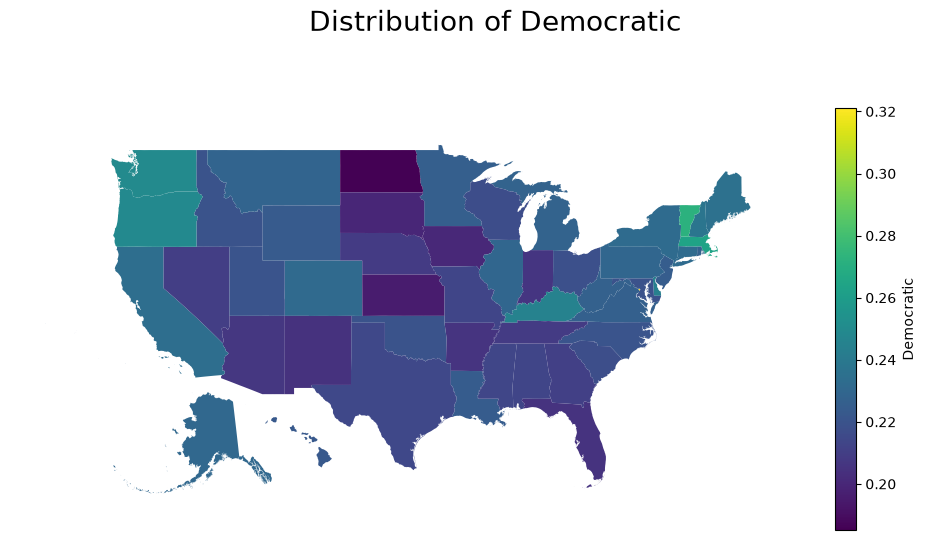

In [18]:

GDP_YOY = float(0.1)#GDP growth rate (minus one) 
INFLATION_YOY = float(0.03) #Inflation rate (minus one)
UNEMPLOYMENT = float(0.08)
INC_TENURE = 8
YEAR = 1972
PARTIES = {
    'Democratic': {
        'inc_pres': 0,
        'i_ideo': 2.5,
        'i_resent': 2.5,
        'poll': 0.46
    },
    'Republican': {
        'inc_pres': 1,
        'i_ideo': 5.5,
        'i_resent': 5.5,
        'poll': 0.46
    },
    'Libertarian': {
        'inc_pres': 0,
        'i_ideo': 5.1,
        'i_resent': 3,
        'poll': 0.04
    },
    'Green': {
        'inc_pres': 0,
        'i_ideo': 1.5,
        'i_resent': 1.5,
        'poll': 0.04
    } 
}

PARTY_NAMES = [party for party in PARTIES]

with open('models/vote_model_i.pickle', 'rb') as file:
    vote_model_i = pickle.load(file)
election_df = pd.read_csv('output_data/anes_cleaned.csv')
#create a table of state leans by modifying state_ideology_timeseries -- necessary because ANES does not include observations from every state
state_lean = (pd.read_csv('raw_data/regression_data.csv')[['year','state','lean_prev','lean_prev2','partisan_lean']]
              .set_index(['year','state'])) #Consider dropping DC before 1964 and imputing remaining 10 missing observations with ffill()
election_df = election_df[election_df['year'] == YEAR].copy() #Think about using the entire sample because we are re-weighting within each time period anyway
#Configure variables in election table based on global election variables
election_df['inc_tenure'] = INC_TENURE
election_df['gdp_yoy'] = GDP_YOY
election_df['inflation_yoy'] = INFLATION_YOY
election_df['unemployment'] = UNEMPLOYMENT
election_df['voter_ideo_numeric'] = election_df['voter_ideo']
election_df['voter_resent_numeric'] = election_df['voter_resent']

non_missing_predictions = vote_model_i.predict(election_df).dropna().index
election_df = election_df.loc[non_missing_predictions] #drop all rows that generate NA predictions

#Re-code ANES ideology and resentment scales to match with labels from state_ideology_time_series
election_df['voter_ideo'] = election_df['voter_ideo'].apply(lambda x: f'ideo_{int(x - 1)}' if pd.notna(x) else np.nan)
election_df['voter_resent'] = election_df['voter_resent'].apply(lambda x: f'resent_{int(x - 1)}' if pd.notna(x) else np.nan)

state_ideology_time_series = pd.read_csv('output_data/state_ideology_ts.csv')
states = state_ideology_time_series['state'].value_counts().keys()
state_election_df = pd.DataFrame()
for state in states:
    print(f'Computing {state}...')
    
    for party in PARTIES: #set inc_pres as interacting variable denoting whether the given party belongs to the incumbent coalition
        election_df['i_ideo'] = PARTIES[party]['i_ideo'] 
        election_df['i_resent'] = PARTIES[party]['i_resent']
        election_df['delta_i_ideo'] = abs(election_df['voter_ideo_numeric'] - election_df['i_ideo'])
        election_df['delta_i_resent'] = abs(election_df['voter_resent_numeric'] - election_df['i_resent'])
        #Predict state vote share as a function of state-level characteristics (lean_prev, lean_prev2)
        #election_df['partisan_lean'] = state_lean.loc[(YEAR,state), 'partisan_lean']
        #election_df['lean_prev'] = state_lean.loc[(YEAR,state), 'lean_prev'] * 100
        #election_df['lean_prev2'] = state_lean.loc[(YEAR,state), 'lean_prev2'] * 100
        
        election_df[party] = vote_model_i.predict(election_df)

    #Normalize vote share within each respondent
    election_df[PARTY_NAMES] = election_df[PARTY_NAMES].div(election_df[PARTY_NAMES].sum(axis = 1), axis = 0)
    
    state_target_marginals = {}
    state_target_marginals['voter_ideo'] = compute_marginals(year = YEAR, state = state, keys = [f'ideo_{x}' for x in range(7)], 
                                               df = state_ideology_time_series.set_index(['year','state']))
    state_target_marginals['voter_resent'] = compute_marginals(year = YEAR, state = state, keys = [f'resent_{x}' for x in range(7)], 
                                               df = state_ideology_time_series.set_index(['year','state']))
    
    state_election_df_curr = rake(sample = election_df, target_marginal_probs=state_target_marginals, rake_keys=['voter_ideo','voter_resent'], weight = 'weightz')
    state_election_df_curr['state'] = state
    state_election_df = pd.concat([state_election_df, state_election_df_curr])

print('Finished re-weighting state samples.')    
state_vote_shares = state_election_df.groupby('state').apply(
    lambda x: x[PARTY_NAMES].mul(x['weightz'], axis=0).sum() / x['weightz'].sum(),
    include_groups=False).reset_index(drop = False)    
state_vote_shares['winner'] = state_vote_shares[PARTY_NAMES].idxmax(axis=1)

states = gpd.read_file("raw_data/greater_us_state_shapefiles/us_states.shp")
states = states.rename(columns={"STUSPS": "state"})
states = states[["state", "geometry"]]

plot_data = states.merge(state_vote_shares, on='state', how="right")

def plot_variable(variable):
    vmin = plot_data[variable].min()
    vmax = plot_data[variable].max()
    cmap = 'viridis'
    
    fig, ax = plt.subplots(figsize=(10, 6))
    plot_data.plot(
        column=variable,
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        legend=False
    )
    
    
    #ax.set_title('Election Result')
    ax.set_axis_off()
    
    norm = Normalize(vmin=vmin, vmax=vmax)
    fig.colorbar(
        ScalarMappable(norm=norm, cmap=cmap),
        ax=ax,
        shrink=0.8,
        label=variable
    )
    
    fig.suptitle(f'Distribution of {variable}', size=20)
    fig.tight_layout()
    plt.show()

plot_variable('Democratic')

In [ ]:
state_ideology_time_series